1. Importing libraries

In [2]:
#%pip install --upgrade pandas pyjanitor

In [1]:
import pandas as pd
import janitor
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno


/home/joe/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/joe/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


2. Loading dataset as dataframe

In [15]:
df = pd.read_csv('../data/Churn_Modelling_f.csv').clean_names()
#df.head(20)

3. Counting nulls by column

In [4]:
total_nulls = df.isnull().sum()
total_nulls

rownumber           0
customerid          0
surname             1
creditscore         1
geography          19
gender              1
age                77
tenure              1
balance             0
numofproducts       0
hascrcard           0
isactivemember      0
estimatedsalary     0
exited              0
dtype: int64

4. Counting nulls by row

In [5]:
nulls_row = df[df.isnull().sum(axis = 1) > 0]
nulls_rows = nulls_row.isnull().sum(axis = 1)
nulls_rows

9       1
19      1
29      1
39      1
49      1
       ..
9899    1
9929    1
9959    1
9989    1
9999    1
Length: 97, dtype: int64

5. Percentage of nulls by column

In [6]:
null_percentage = (total_nulls / len(df)) * 100
null_percentage

rownumber          0.00
customerid         0.00
surname            0.01
creditscore        0.01
geography          0.19
gender             0.01
age                0.77
tenure             0.01
balance            0.00
numofproducts      0.00
hascrcard          0.00
isactivemember     0.00
estimatedsalary    0.00
exited             0.00
dtype: float64

6. Function for reporting

In [7]:
def null_report(dataframe):
    report = pd.DataFrame({'Variable': total_nulls.index,'#_Nulls':total_nulls.values,'%':null_percentage.values})
    report = report[report['#_Nulls'] > 0].sort_values(by = '#_Nulls', ascending=False)
    return report

In [8]:
null_report(df)

,Variable,#_Nulls,%
6,age,77,0.77
4,geography,19,0.19
3,creditscore,1,0.01
2,surname,1,0.01
5,gender,1,0.01
7,tenure,1,0.01


7. Nulls chart by column

In [9]:
def null_chart(report):
    if report.empty:
        print("No nulls to show in a figure")
        return
    
    plt.figure(figsize = (10,6))
    sns.set_style("whitegrid")

    plot = sns.barplot(data = report, x = '#_Nulls', y = 'Variable', palette = 'viridis')
    plt.title('Null distribution by column', fontsize = 14, pad = 20 )
    sns.despine(left = True, bottom = True)
    plt.show()
    

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


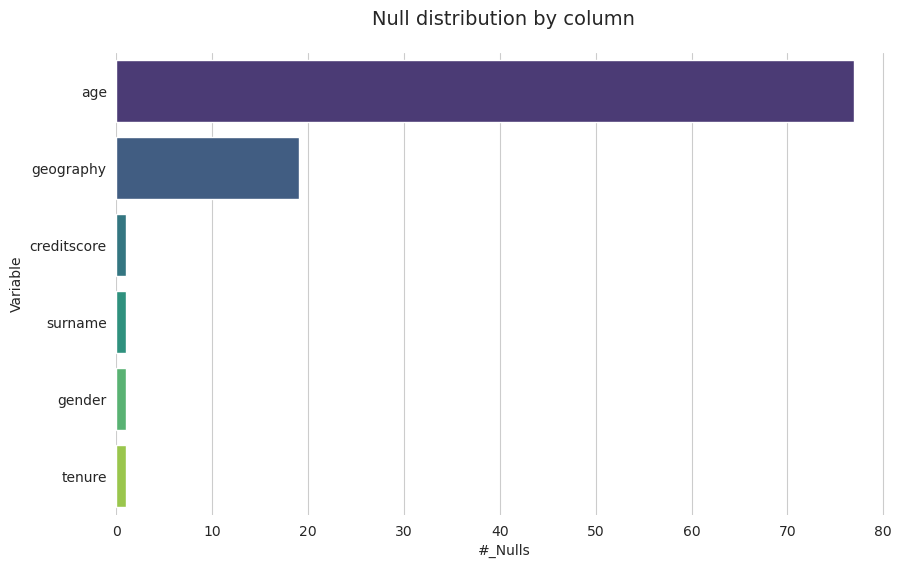

In [10]:
null_chart(null_report(df))

8. Nulls chart by row ocurrence

In [12]:
def nulls_row_chart(nulls_byrow):
    plt.figure(figsize = (10,6))
    sns.set_style("ticks")
    gr = sns.countplot(x = nulls_byrow, palette = 'magma')
    plt.title('Missings by row', fontsize = 14, pad = 20 )
    plt.xlabel('Missing quantities by row')
    plt.ylabel('Rows quantity')
    #gr.set_yticks(np.arange(0,101,5))
    #sns.despine(left = True, bottom = True)
    plt.show()

/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/joe/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


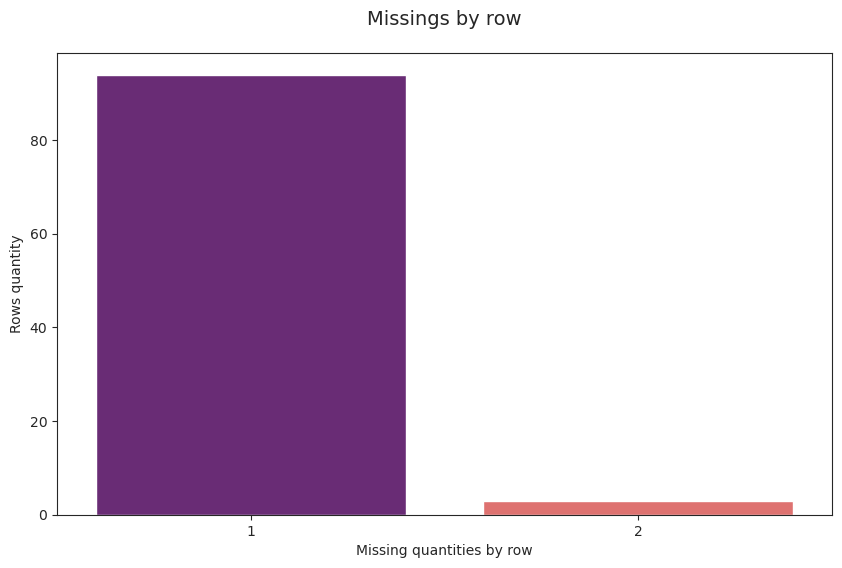

In [13]:
nulls_row_chart(nulls_rows)

9. Heatmap, useful to find correlation between missing values

<Axes: >

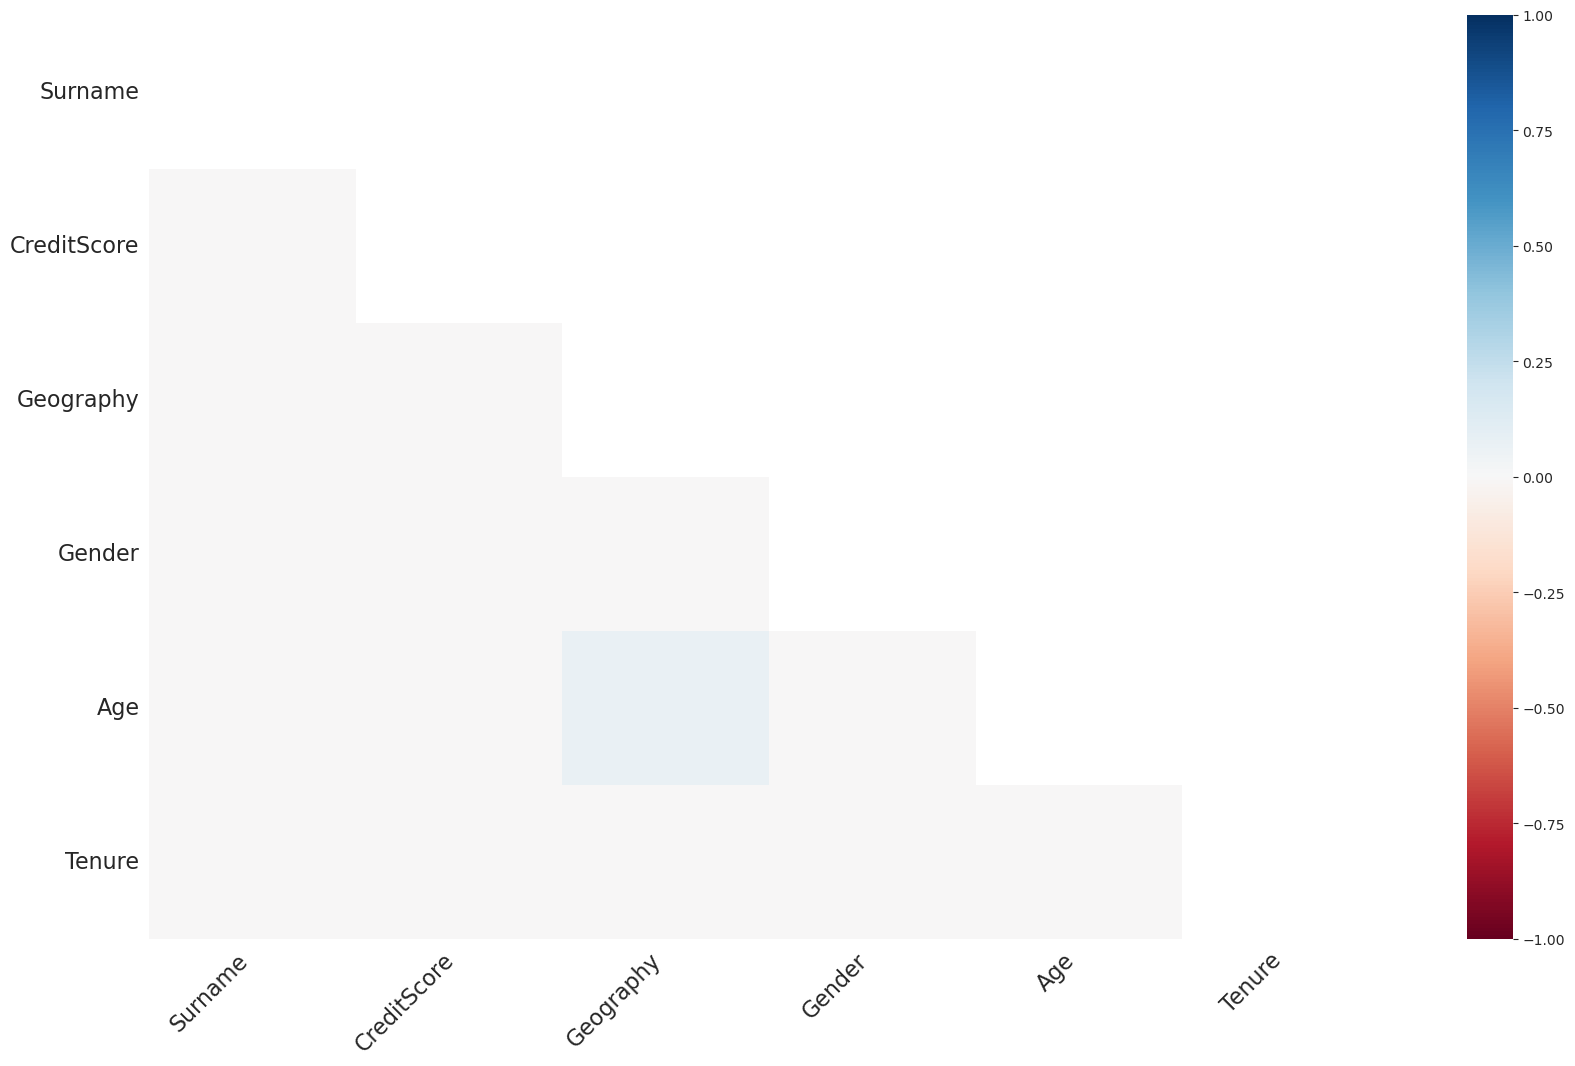

In [30]:
msno.heatmap(df, labels = False)

10. Matrix of missing values, it worws for evaluating trends on missing value.

<Axes: >

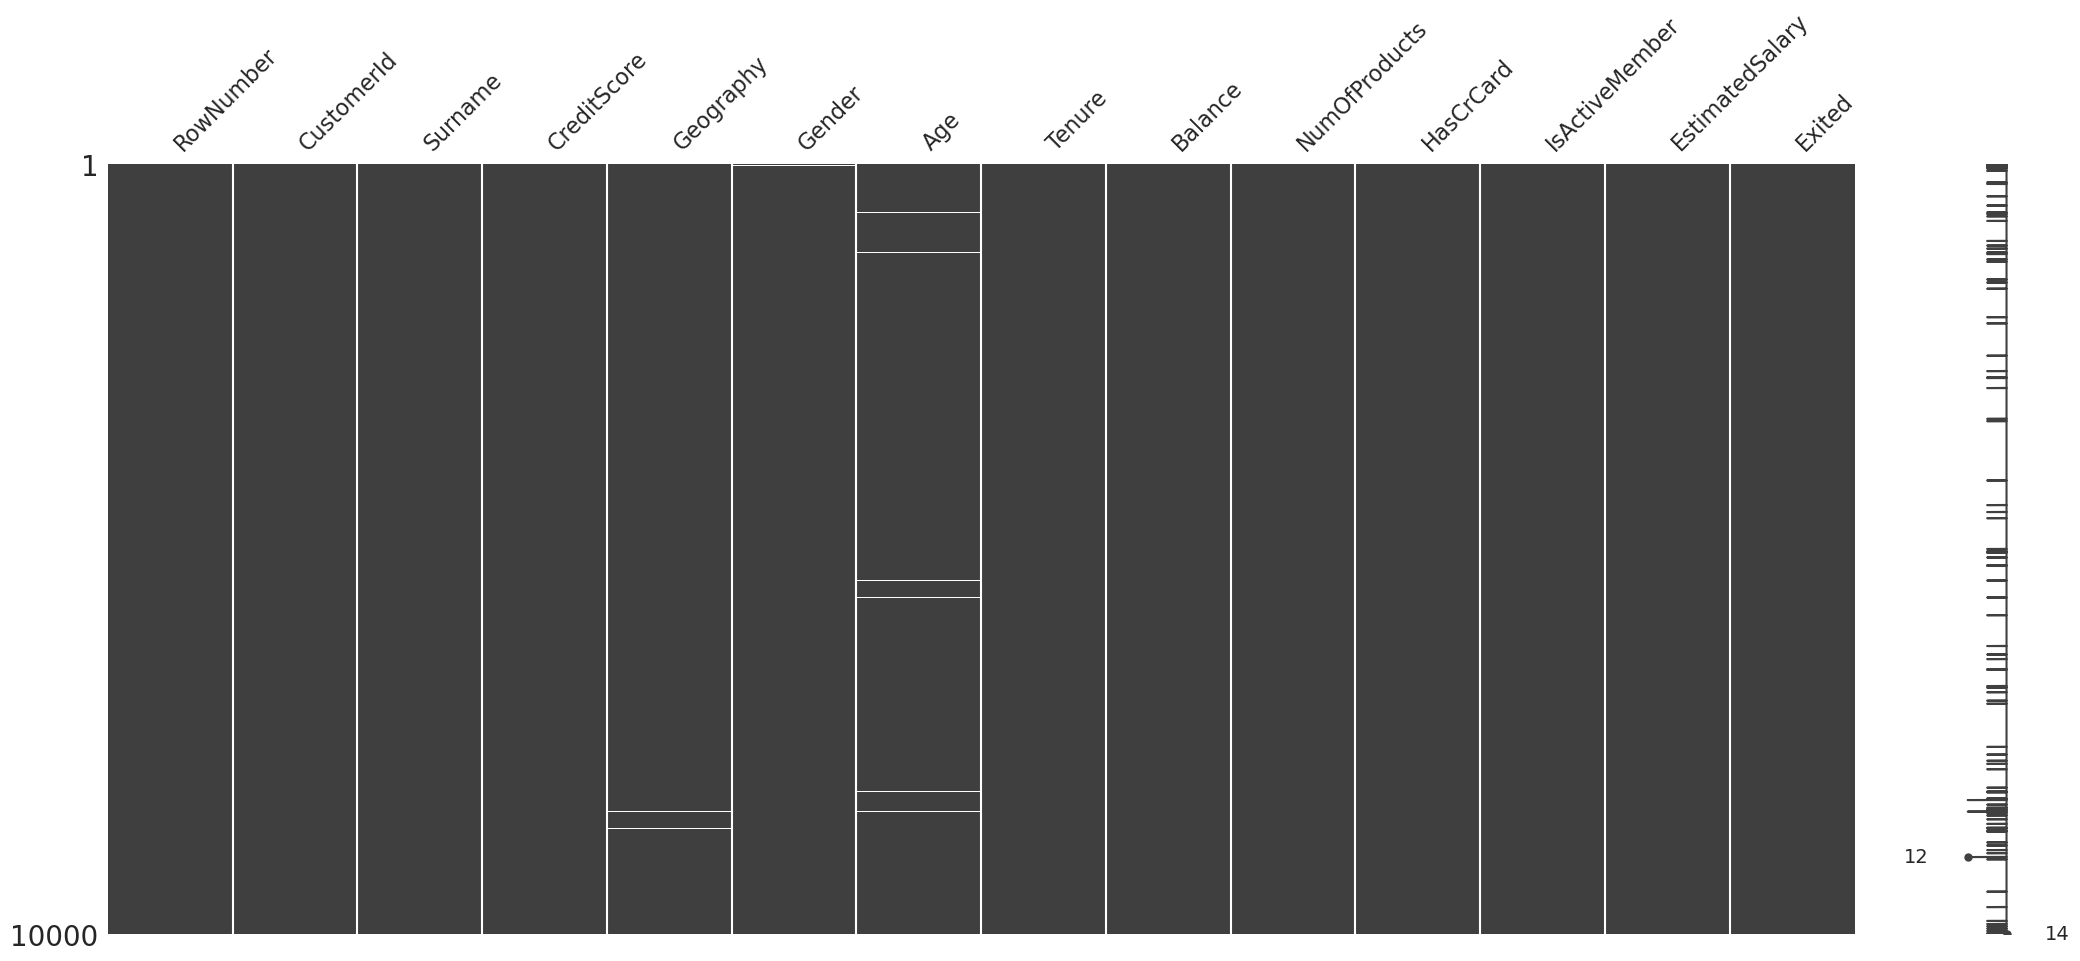

In [31]:
msno.matrix(df)

<Axes: >

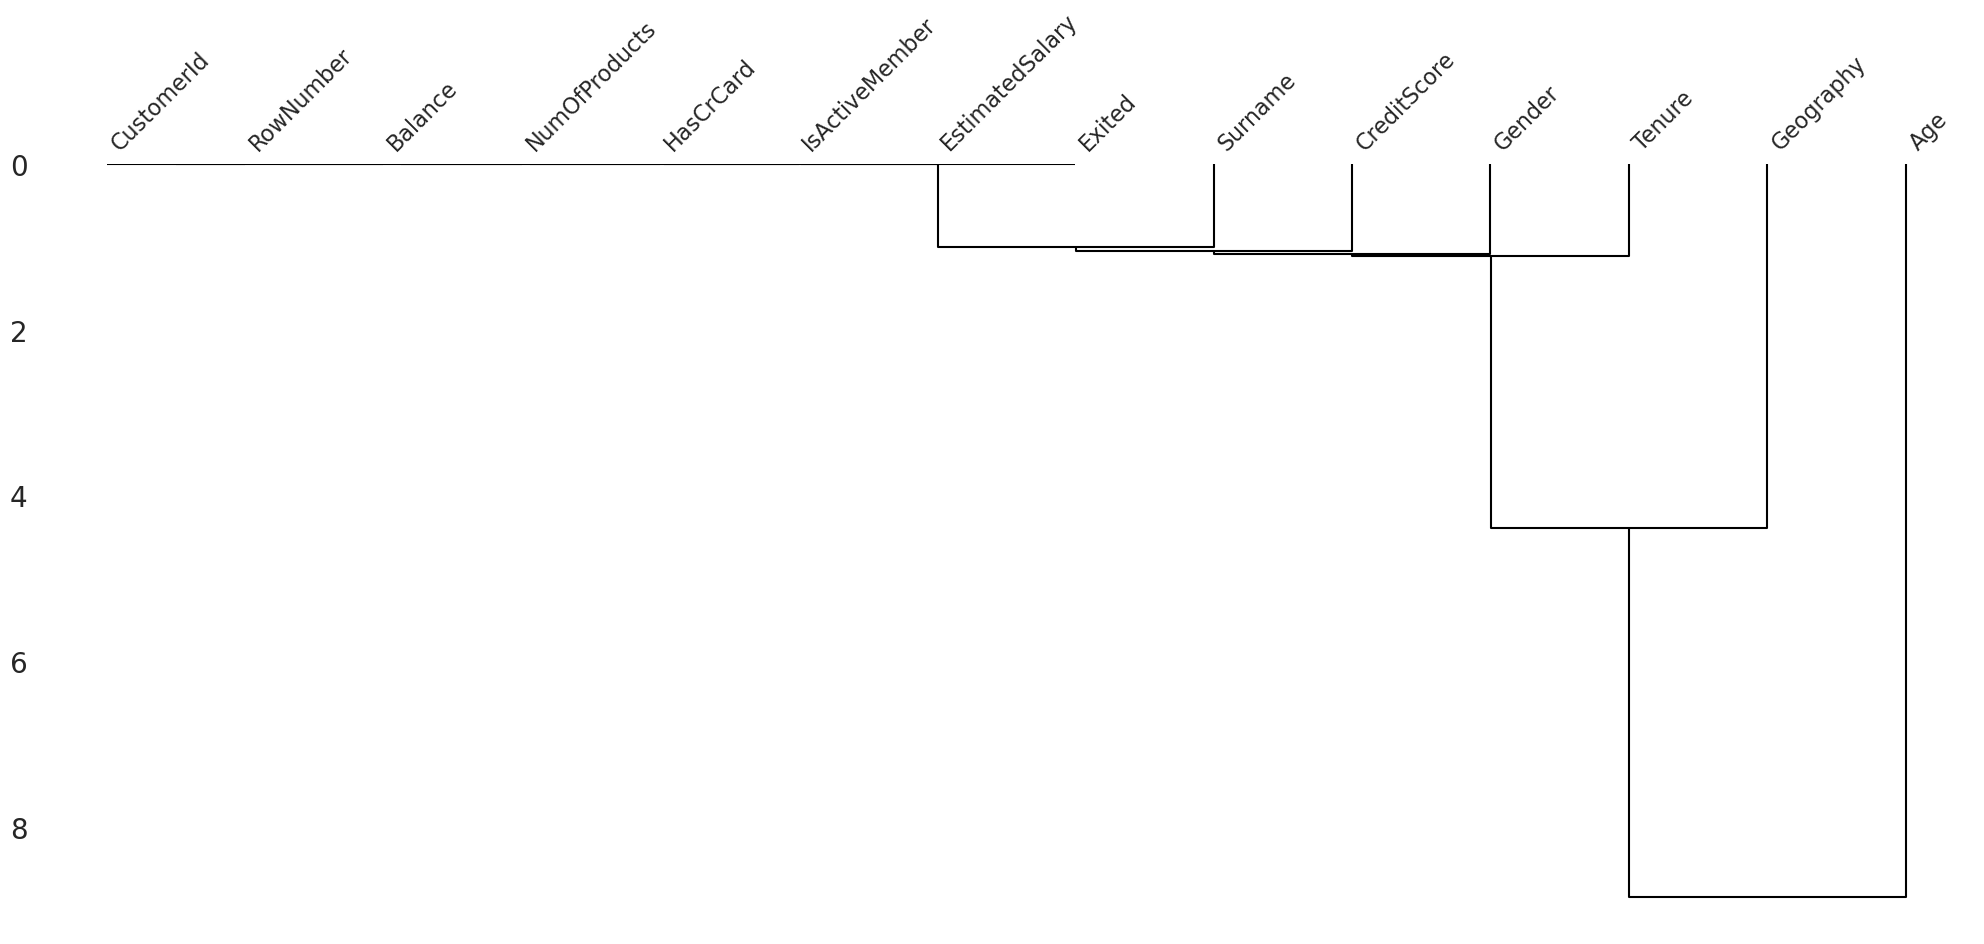

In [32]:
msno.dendrogram(df)

In [16]:
df.to_csv('../data/Modelling_nulls.csv')